In [ ]:
# Mount Google Drive (if running in Colab) to access data
from google.colab import drive
drive.mount('/content/drive')

# Import libraries
import os, glob
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# Check device (use GPU if available for faster training)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Mounted at /content/drive
Using device: cuda


In [ ]:
# Paths to train and val directories
train_dir = "/content/drive/MyDrive/DL_Project/Skin_Cancer_Classification_DL_Project/train"
val_dir   = "/content/drive/MyDrive/DL_Project/Skin_Cancer_Classification_DL_Project/val"

# Get all training file paths
train_files = glob.glob(os.path.join(train_dir, "*.*"))  # list all files in train directory
print(f"Found {len(train_files)} training images.")

# Count images per class in training set
class_counts = {i: 0 for i in range(1, 8)}  # classes 1-7
for filepath in train_files:
    # Assume filename format like '1_filename.jpg'
    filename = os.path.basename(filepath)
    if "_" in filename:
        label_str = filename.split("_")[0]
    else:
        # If no underscore, take first character (should be class number)
        label_str = filename[0]
    try:
        label = int(label_str)
        if 1 <= label <= 7:
            class_counts[label] += 1
    except:
        continue

# Display original class distribution
print("Original class counts:", class_counts)

# Determine the target count for balancing
min_count = min(class_counts.values())
max_count = max(class_counts.values())
# We limit oversampling to at most 10x the smallest class count:
target_count = min(max_count, 15 * min_count)
print(f"Smallest class has {min_count} images, largest has {max_count}.")
print(f"Target samples per class after balancing = {target_count}.")

Found 3010 training images.
Original class counts: {1: 113, 2: 148, 3: 346, 4: 36, 5: 253, 6: 2079, 7: 35}
Smallest class has 35 images, largest has 2079.
Target samples per class after balancing = 525.


In [ ]:
import random
random.seed(42)

balanced_train_samples = []  # will hold (filepath, label) tuples
minority_classes = []        # track which classes were oversampled

for cls, count in class_counts.items():
    if count == 0:
        continue  # just in case, skip classes not present at all
    if count > target_count:
        # Down-sample: randomly choose target_count files
        chosen_files = random.sample([f for f in train_files if f"{cls}_" in os.path.basename(f) or os.path.basename(f).startswith(str(cls))],
                                     target_count)
        for f in chosen_files:
            balanced_train_samples.append((f, cls))
    elif count < target_count:
        minority_classes.append(cls)
        files_cls = [f for f in train_files if f"{cls}_" in os.path.basename(f) or os.path.basename(f).startswith(str(cls))]
        # Determine how many times to replicate the full set
        reps = target_count // count  # full repetitions
        rem  = target_count % count   # remainder to sample additionally
        # Add full repetitions of all images
        balanced_train_samples.extend([(f, cls) for f in files_cls] * reps)
        # Add a random subset for the remainder
        if rem > 0:
            extra_files = random.choices(files_cls, k=rem)
            balanced_train_samples.extend([(f, cls) for f in extra_files])
    else:
        # Exactly target_count (or if count == target_count, just take all)
        balanced_train_samples.extend([(f, cls) for f in train_files
                                       if f"{cls}_" in os.path.basename(f) or os.path.basename(f).startswith(str(cls))])

# Shuffle the balanced list
random.shuffle(balanced_train_samples)
# Print new class counts to verify roughly balanced
new_counts = {i: 0 for i in range(1, 8)}
for _, cls in balanced_train_samples:
    new_counts[cls] += 1
print("Balanced class counts:", new_counts)
print(f"Total training samples after balancing: {len(balanced_train_samples)}")
print("Minority classes (augmented):", minority_classes)

Balanced class counts: {1: 525, 2: 525, 3: 525, 4: 525, 5: 525, 6: 525, 7: 525}
Total training samples after balancing: 3675
Minority classes (augmented): [1, 2, 3, 4, 5, 7]


In [ ]:
# Define image size and normalization (using ImageNet stats)
IMG_SIZE = 300  # we'll use 300x300 as input size
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

# Base transform for majority classes: minimal augmentation
base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),   # ensure image is 300x300 (if not already)
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Augmentation transform for minority classes: add random flips/rotations, etc.
aug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20, fill=(0,0,0)),  # random rotation up to 20 degrees
    # Optionally, we can add slight random brightness/contrast adjustments since images are grayscale
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [ ]:
class SkinCancerDataset(Dataset):
    def __init__(self, samples, minority_classes=None, aug_transform=None, base_transform=None):
        """
        samples: list of (filepath, label) tuples
        minority_classes: list or set of class indices that should get augmented transform
        aug_transform: torchvision transform to apply for minority class images
        base_transform: torchvision transform for majority class images
        """
        self.samples = samples
        self.minority_classes = set(minority_classes) if minority_classes is not None else set()
        self.aug_transform = aug_transform
        self.base_transform = base_transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        image = Image.open(filepath)
        # Convert grayscale to RGB (just duplicates channel) if image is not already 3-channel
        if image.mode != 'RGB':
            image = image.convert("RGB")
        # Parse label: ensure it's 0-indexed for PyTorch
        # (Here, we assume label is already int 1-7 from our list, we'll subtract 1)
        class_idx = label - 1

        # Apply transforms
        if self.aug_transform is not None and label in self.minority_classes:
            # Use augmentation transform for minority class image
            img_tensor = self.aug_transform(image)
        else:
            # Use base transform for majority class or if no aug_transform provided
            img_tensor = self.base_transform(image) if self.base_transform else transforms.ToTensor()(image)
            if self.base_transform is None:
                # If no base_transform, we still normalize
                img_tensor = transforms.Normalize(mean, std)(img_tensor)

        return img_tensor, class_idx

# Create Dataset instances for train and validation
train_dataset = SkinCancerDataset(balanced_train_samples, minority_classes=minority_classes,
                                  aug_transform=aug_transform, base_transform=base_transform)
val_files = glob.glob(os.path.join(val_dir, "*.*"))
val_samples = []
for f in val_files:
    name = os.path.basename(f)
    if "_" in name:
        cls = int(name.split("_")[0])
    else:
        cls = int(name[0])
    val_samples.append((f, cls))
# We won't augment validation, so pass aug_transform=None and just use base_transform
val_dataset = SkinCancerDataset(val_samples, minority_classes=None, aug_transform=None, base_transform=base_transform)

print(f"Total validation images: {len(val_dataset)}")

Total validation images: 1000


In [ ]:
# Create DataLoader for train and val
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [ ]:
# Load MobileNet V2 with pretrained weights
model_v2 = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V2)
# Modify the classifier to output 7 classes
# MobileNetV2's classifier is: Sequential(Dropout, Linear(1280 -> 1000))
model_v2.classifier[1] = nn.Linear(model_v2.classifier[1].in_features, 7)
model_v2 = model_v2.to(device)

# Load MobileNet V3-Large (no pretraining)
model_v3 = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
# Modify the classifier to output 7 classes
# MobileNetV3's classifier is: Sequential( Linear(last_channel->last_channel), Hardswish, Dropout, Linear(last_channel->1000) )
# The last Linear is index 3 in the classifier Sequential
model_v3.classifier[3] = nn.Linear(model_v3.classifier[3].in_features, 7)
model_v3 = model_v3.to(device)

print("MobileNet V2 and V3 models initialized.")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 85.8MB/s]
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 81.4MB/s]


MobileNet V2 and V3 models initialized.


In [ ]:
# Calculate class weights for the loss function (using original training distribution)
total_images = sum(class_counts.values())
num_classes = len(class_counts)
class_weights = []
for cls in range(1, num_classes+1):
    if class_counts[cls] != 0:
        # weight = total_samples / (num_classes * count[cls])
        w = total_images / (num_classes * class_counts[cls])
    else:
        w = 0.0
    class_weights.append(w)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights.cpu().numpy())

# Define loss criterion with weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizers for both models (we can use Adam optimizer)
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=0.001)
optimizer_v3 = torch.optim.Adam(model_v3.parameters(), lr=0.001)

Class weights: [ 3.8053098  2.9054055  1.2427746 11.944445   1.6996047  0.2068302
 12.285714 ]


In [ ]:
# Training loop for MobileNet V2
epochs = 15
train_loss_v2, val_loss_v2 = [], []
train_acc_v2, val_acc_v2 = [], []

for epoch in range(1, epochs+1):
    model_v2.train()
    running_loss = 0.0
    correct = 0
    total = 0
    # Training
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_v2.zero_grad()
        outputs = model_v2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_v2.step()
        # accumulate loss
        running_loss += loss.item() * images.size(0)
        # accumulate accuracy
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    # Validation
    model_v2.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_v2(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total

    # Record metrics
    train_loss_v2.append(epoch_train_loss)
    val_loss_v2.append(epoch_val_loss)
    train_acc_v2.append(epoch_train_acc)
    val_acc_v2.append(epoch_val_acc)

    # Print epoch summary
    print(f"Epoch {epoch}/{epochs} - MobileNet V2: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc*100:.2f}%, "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc*100:.2f}%")

Epoch 1/15 - MobileNet V2: Train Loss: 0.8808, Train Acc: 41.66%, Val Loss: 1.9714, Val Acc: 13.10%
Epoch 2/15 - MobileNet V2: Train Loss: 0.4757, Train Acc: 54.56%, Val Loss: 2.1725, Val Acc: 16.10%
Epoch 3/15 - MobileNet V2: Train Loss: 0.3552, Train Acc: 62.23%, Val Loss: 1.7523, Val Acc: 40.80%
Epoch 4/15 - MobileNet V2: Train Loss: 0.3244, Train Acc: 69.28%, Val Loss: 2.1389, Val Acc: 37.20%
Epoch 5/15 - MobileNet V2: Train Loss: 0.2990, Train Acc: 71.27%, Val Loss: 1.8657, Val Acc: 64.20%
Epoch 6/15 - MobileNet V2: Train Loss: 0.2173, Train Acc: 77.63%, Val Loss: 2.6326, Val Acc: 61.40%
Epoch 7/15 - MobileNet V2: Train Loss: 0.1942, Train Acc: 80.52%, Val Loss: 1.8606, Val Acc: 65.30%
Epoch 8/15 - MobileNet V2: Train Loss: 0.1702, Train Acc: 83.59%, Val Loss: 2.9822, Val Acc: 69.60%
Epoch 9/15 - MobileNet V2: Train Loss: 0.1352, Train Acc: 85.99%, Val Loss: 2.2738, Val Acc: 62.60%
Epoch 10/15 - MobileNet V2: Train Loss: 0.0978, Train Acc: 88.24%, Val Loss: 2.7684, Val Acc: 69.00%

In [ ]:
# Save the trained MobileNet V2 model weights
model_v2_path = "/content/drive/MyDrive/MobileNetV2_weights.pt"
torch.save(model_v2.state_dict(), model_v2_path)
print("Saved MobileNet V2 model weights.")

Saved MobileNet V2 model weights.


In [ ]:
# Training loop for MobileNet V3-Large
epochs = 15
train_loss_v3, val_loss_v3 = [], []
train_acc_v3, val_acc_v3 = [], []

for epoch in range(1, epochs+1):
    model_v3.train()
    running_loss = 0.0
    correct = 0
    total = 0
    # Training phase
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_v3.zero_grad()
        outputs = model_v3(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_v3.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    # Validation phase
    model_v3.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_v3(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total

    train_loss_v3.append(epoch_train_loss)
    val_loss_v3.append(epoch_val_loss)
    train_acc_v3.append(epoch_train_acc)
    val_acc_v3.append(epoch_val_acc)

    print(f"Epoch {epoch}/{epochs} - MobileNet V3: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc*100:.2f}%, "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc*100:.2f}%")

Epoch 1/15 - MobileNet V3: Train Loss: 0.8357, Train Acc: 42.10%, Val Loss: 2.4264, Val Acc: 10.70%
Epoch 2/15 - MobileNet V3: Train Loss: 0.4944, Train Acc: 57.90%, Val Loss: 2.1962, Val Acc: 25.80%
Epoch 3/15 - MobileNet V3: Train Loss: 0.3266, Train Acc: 69.14%, Val Loss: 1.9591, Val Acc: 55.20%
Epoch 4/15 - MobileNet V3: Train Loss: 0.2905, Train Acc: 73.25%, Val Loss: 2.6112, Val Acc: 53.00%
Epoch 5/15 - MobileNet V3: Train Loss: 0.2601, Train Acc: 74.29%, Val Loss: 1.8850, Val Acc: 30.10%
Epoch 6/15 - MobileNet V3: Train Loss: 0.2752, Train Acc: 75.84%, Val Loss: 2.3657, Val Acc: 48.10%
Epoch 7/15 - MobileNet V3: Train Loss: 0.1619, Train Acc: 83.70%, Val Loss: 2.5903, Val Acc: 68.30%
Epoch 8/15 - MobileNet V3: Train Loss: 0.1251, Train Acc: 85.77%, Val Loss: 2.5467, Val Acc: 48.50%
Epoch 9/15 - MobileNet V3: Train Loss: 0.1467, Train Acc: 85.03%, Val Loss: 4.1383, Val Acc: 69.20%
Epoch 10/15 - MobileNet V3: Train Loss: 0.1143, Train Acc: 86.29%, Val Loss: 2.5122, Val Acc: 65.20%

In [ ]:
# Save the trained MobileNet V3 model weights
import torch
model_v3_path = "/content/drive/MyDrive/MobileNetV3_weights.pt"
torch.save(model_v3.state_dict(), model_v3_path)
print("Saved MobileNet V3 model weights.")

Saved MobileNet V3 model weights.


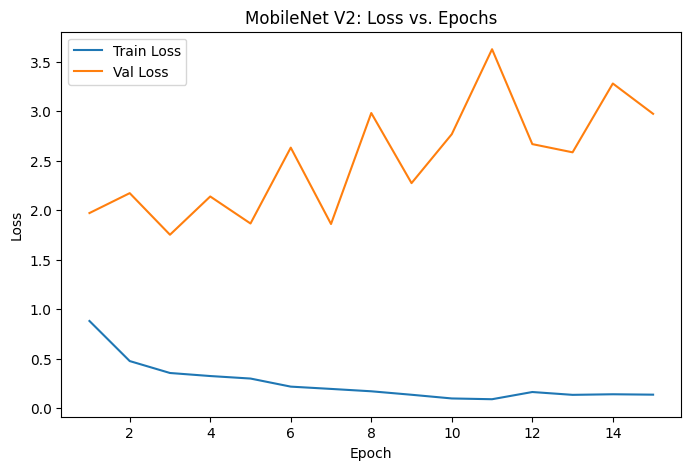

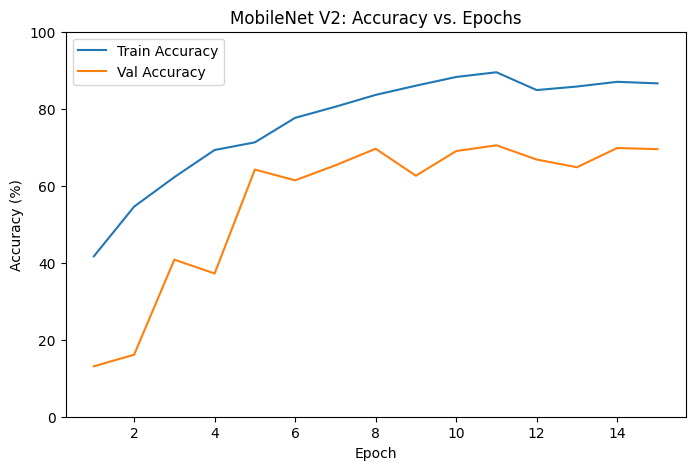

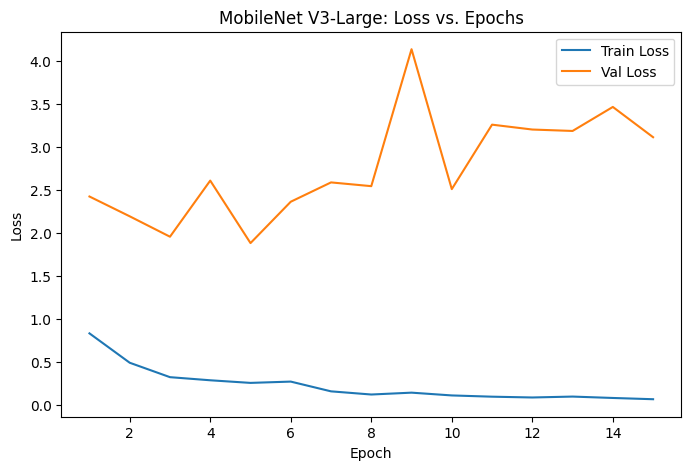

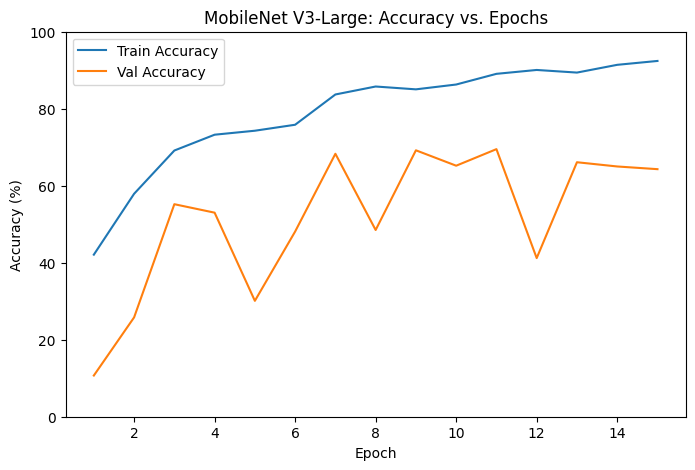

In [ ]:
import matplotlib.pyplot as plt

# Plot loss curves for MobileNet V2
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_loss_v2, label="Train Loss")
plt.plot(range(1, epochs+1), val_loss_v2, label="Val Loss")
plt.title("MobileNet V2: Loss vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot accuracy curves for MobileNet V2
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), [x*100 for x in train_acc_v2], label="Train Accuracy")
plt.plot(range(1, epochs+1), [x*100 for x in val_acc_v2], label="Val Accuracy")
plt.title("MobileNet V2: Accuracy vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.legend()
plt.show()

# Plot loss curves for MobileNet V3
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_loss_v3, label="Train Loss")
plt.plot(range(1, epochs+1), val_loss_v3, label="Val Loss")
plt.title("MobileNet V3-Large: Loss vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot accuracy curves for MobileNet V3
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), [x*100 for x in train_acc_v3], label="Train Accuracy")
plt.plot(range(1, epochs+1), [x*100 for x in val_acc_v3], label="Val Accuracy")
plt.title("MobileNet V3-Large: Accuracy vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.legend()
plt.show()

In [ ]:

class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

def evaluate_model(model, loader):
    model.eval()
    class_correct = [0]*7
    class_total = [0]*7
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            # accumulate for each class
            for label, pred in zip(labels.cpu().numpy(), preds.cpu().numpy()):
                class_total[label] += 1
                if pred == label:
                    class_correct[label] += 1
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
    # Calculate accuracy per class
    class_acc = {}
    for i in range(7):
        if class_total[i] > 0:
            class_acc[class_names[i]] = 100 * class_correct[i] / class_total[i]
        else:
            class_acc[class_names[i]] = None  # no samples of this class
    # Overall accuracy
    overall_acc = 100 * sum(class_correct) / sum(class_total)
    return overall_acc, class_acc, all_preds, all_labels

# Evaluate MobileNet V2
val_acc_v2_percent, class_acc_v2, preds_v2, labels_v2 = evaluate_model(model_v2, val_loader)
print(f"\nMobileNet V2 Validation Accuracy: {val_acc_v2_percent:.2f}%")
for cls_name, acc in class_acc_v2.items():
    if acc is not None:
        print(f"  Class '{cls_name}' accuracy: {acc:.2f}%")
    else:
        print(f"  Class '{cls_name}' accuracy: N/A (no samples in val set)")

# Evaluate MobileNet V3
val_acc_v3_percent, class_acc_v3, preds_v3, labels_v3 = evaluate_model(model_v3, val_loader)
print(f"\nMobileNet V3-Large Validation Accuracy: {val_acc_v3_percent:.2f}%")
for cls_name, acc in class_acc_v3.items():
    if acc is not None:
        print(f"  Class '{cls_name}' accuracy: {acc:.2f}%")
    else:
        print(f"  Class '{cls_name}' accuracy: N/A")


MobileNet V2 Validation Accuracy: 69.50%
  Class 'akiec' accuracy: 52.78%
  Class 'bcc' accuracy: 48.33%
  Class 'bkl' accuracy: 12.75%
  Class 'df' accuracy: 13.33%
  Class 'mel' accuracy: 20.62%
  Class 'nv' accuracy: 90.60%
  Class 'vasc' accuracy: 25.00%

MobileNet V3-Large Validation Accuracy: 64.30%
  Class 'akiec' accuracy: 61.11%
  Class 'bcc' accuracy: 35.00%
  Class 'bkl' accuracy: 25.49%
  Class 'df' accuracy: 20.00%
  Class 'mel' accuracy: 61.86%
  Class 'nv' accuracy: 75.82%
  Class 'vasc' accuracy: 15.00%


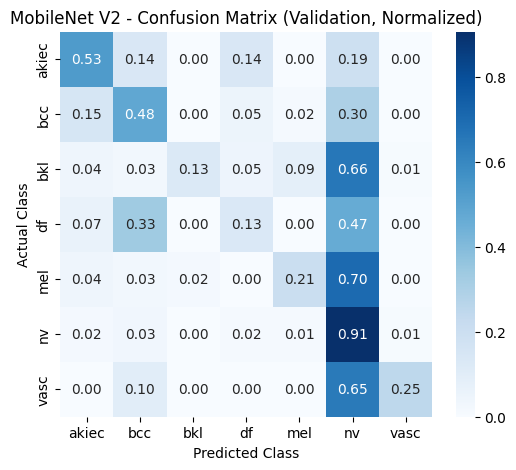

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute normalized confusion matrix (row-wise probabilities)
cm_v2_prob = confusion_matrix(labels_v2, preds_v2, normalize='true')

plt.figure(figsize=(6, 5))
sns.heatmap(cm_v2_prob, annot=True, fmt='.2f', cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("MobileNet V2 - Confusion Matrix (Validation, Normalized)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

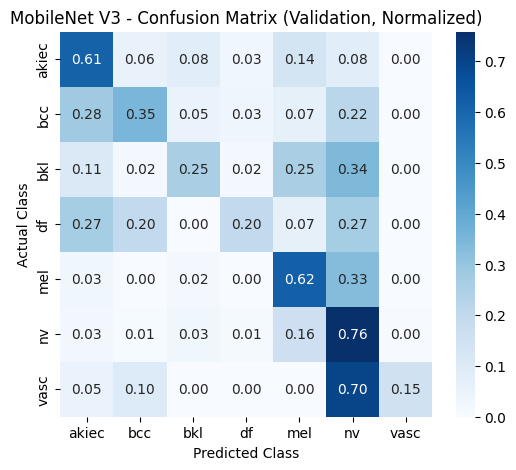

In [ ]:
# Compute normalized confusion matrix (row-wise probabilities)
cm_v3_prob = confusion_matrix(labels_v3, preds_v3, normalize='true')

plt.figure(figsize=(6, 5))
sns.heatmap(cm_v3_prob, annot=True, fmt='.2f', cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("MobileNet V3 - Confusion Matrix (Validation, Normalized)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

# Testing

Link for weights to model1:

https://drive.google.com/file/d/1vDM8qrbBZb7qw38WAygb8IiADNiNHrXf/view?usp=share_link

Link for weights to model2:

https://drive.google.com/file/d/1-3IGQiQB4kZBJbUgZ7F_p8eprH7IhQIR/view?usp=share_link

In [ ]:
# --------- SETUP ---------
from google.colab import drive
drive.mount('/content/drive')
import os
from PIL import Image
import torch
import torchvision.transforms as transforms
import torchvision.models as models

# Choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class labels (same order as training)
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
num_classes = len(class_names)

# --------- 1. DEFINE MODEL (e.g. MobileNetV2) ---------
def get_mobilenet_v2():
    model = models.mobilenet_v2(pretrained=False)
    model.classifier[1] = torch.nn.Linear(model.last_channel, num_classes)
    return model.to(device)

# --------- 2. LOAD SAVED WEIGHTS ---------
model = get_mobilenet_v2()
model.load_state_dict(torch.load("/content/drive/MyDrive/MobileNetV2_weights.pt"))
model.eval()

# --------- 3. DEFINE TRANSFORMS ---------
test_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# --------- 4. RUN ON TEST DATA ---------
def predict_on_directory(model, test_dir, transform):
    model.eval()
    for fname in os.listdir(test_dir):
        if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
            path = os.path.join(test_dir, fname)
            img = Image.open(path).convert("RGB")
            img_tensor = transform(img).unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(img_tensor)
                pred = torch.argmax(output, dim=1).item()
                print(f"{fname} → {class_names[pred]}")

# --------- 5. SET YOUR TEST FOLDER PATH HERE ---------
test_dir = "/content/drive/MyDrive/DL_Project/Skin_Cancer_Classification_DL_Project/test"
predict_on_directory(model, test_dir, test_transform)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


3_image_76.jpg → nv
2_image_98.jpg → vasc
5_image_8.jpg → nv
7_image_70.jpg → nv
6_image_41.jpg → nv
2_image_106.jpg → nv
3_image_78.jpg → nv
5_image_95.jpg → nv
2_image_126.jpg → nv
2_image_40.jpg → nv
5_image_144.jpg → nv
1_image_163.jpg → nv
2_image_167.jpg → nv
3_image_103.jpg → nv
5_image_28.jpg → nv
2_image_592.jpg → nv
2_image_268.jpg → nv
2_image_482.jpg → nv
7_image_562.jpg → nv
5_image_335.jpg → nv
5_image_347.jpg → nv
2_image_245.jpg → nv
2_image_360.jpg → nv
3_image_467.jpg → nv
3_image_330.jpg → nv
3_image_242.jpg → nv
2_image_644.jpg → nv
3_image_469.jpg → nv
3_image_566.jpg → nv
3_image_391.jpg → nv
5_image_424.jpg → nv
5_image_451.jpg → nv
2_image_361.jpg → nv
3_image_371.jpg → nv
7_image_599.jpg → nv
2_image_961.jpg → nv
3_image_1210.jpg → nv
7_image_945.jpg → nv
2_image_2683.jpg → nv
4_image_3571.jpg → nv
4_image_3422.jpg → nv
7_image_3551.jpg → nv
4_image_3308.jpg → nv
1_image_4194.jpg → nv
1_image_4076.jpg → nv
1_image_4065.jpg → nv
4_image_4621.jpg → nv
2_image_457

In [ ]:
# --------- SETUP ---------
from google.colab import drive
drive.mount('/content/drive')
import os
from PIL import Image
import torch
import torchvision.transforms as transforms
import torchvision.models as models

# Choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class labels (same order as training)
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
num_classes = len(class_names)

# --------- 1. DEFINE MODEL (MobileNetV3-Large) ---------
def get_mobilenet_v3():
    model = models.mobilenet_v3_large(pretrained=False)
    model.classifier[3] = torch.nn.Linear(model.classifier[3].in_features, num_classes)
    return model.to(device)

# --------- 2. LOAD SAVED WEIGHTS ---------
model = get_mobilenet_v3()
model.load_state_dict(torch.load("/content/drive/MyDrive/DL_Project/MobileNetV3_weights.pt"))
model.eval()

# --------- 3. DEFINE TRANSFORMS ---------
test_transform = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# --------- 4. RUN ON TEST DATA ---------
def predict_on_directory(model, test_dir, transform):
    model.eval()
    for fname in os.listdir(test_dir):
        if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
            path = os.path.join(test_dir, fname)
            img = Image.open(path).convert("RGB")
            img_tensor = transform(img).unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(img_tensor)
                pred = torch.argmax(output, dim=1).item()
                print(f"{fname} → {class_names[pred]}")

# --------- 5. SET YOUR TEST FOLDER PATH HERE ---------
test_dir = "/content/drive/MyDrive/DL_Project/Skin_Cancer_Classification_DL_Project/test"
predict_on_directory(model, test_dir, test_transform)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
3_image_76.jpg → vasc
2_image_98.jpg → nv
5_image_8.jpg → nv
7_image_70.jpg → vasc
6_image_41.jpg → vasc
2_image_106.jpg → bkl
3_image_78.jpg → vasc
5_image_95.jpg → nv
2_image_126.jpg → bkl
2_image_40.jpg → vasc
5_image_144.jpg → nv
1_image_163.jpg → nv
2_image_167.jpg → bkl
3_image_103.jpg → vasc
5_image_28.jpg → vasc
2_image_592.jpg → vasc
2_image_268.jpg → vasc
2_image_482.jpg → vasc
7_image_562.jpg → vasc
5_image_335.jpg → vasc
5_image_347.jpg → nv
2_image_245.jpg → vasc
2_image_360.jpg → vasc
3_image_467.jpg → vasc
3_image_330.jpg → bkl
3_image_242.jpg → nv
2_image_644.jpg → vasc
3_image_469.jpg → vasc
3_image_566.jpg → nv
3_image_391.jpg → bkl
5_image_424.jpg → nv
5_image_451.jpg → vasc
2_image_361.jpg → nv
3_image_371.jpg → bkl
7_image_599.jpg → vasc
2_image_961.jpg → nv
3_image_1210.jpg → bkl
7_image_945.jpg → bkl
2_image_2683.jpg → nv
4_image_3571.j